In [42]:
import pandas as pd

In [43]:
df = pd.read_csv("train.csv")

In [44]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [45]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
df.shape

(891, 12)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [48]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [49]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [50]:
print("Survived:", df["Survived"].unique())
print("Pclass:", df["Pclass"].unique())
print("Sex:", df["Sex"].unique())
print("Embarked:", df["Embarked"].unique())

Survived: [0 1]
Pclass: [3 1 2]
Sex: <ArrowStringArray>
['male', 'female']
Length: 2, dtype: str
Embarked: <ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [51]:
print(df["Survived"].value_counts())
print(df["Sex"].value_counts())
print(df["Pclass"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [52]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [53]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [54]:
missing = df.isnull().sum()
missing[missing > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [55]:
df["Age"].median()

np.float64(28.0)

In [56]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [57]:
df["Age"].isnull().sum()

np.int64(0)

In [58]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [59]:
df["Embarked"].mode()[0]

'S'

In [60]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [61]:
df["Embarked"].isnull().sum()

np.int64(0)

In [62]:
""" Cabin has a large number of missing values.
Rather than trying to guess individual cabin numbers, 
we will keep the information in a useful form by creating a new feature that tells us whether a cabin number was recorded."""

' Cabin has a large number of missing values.\nRather than trying to guess individual cabin numbers, \nwe will keep the information in a useful form by creating a new feature that tells us whether a cabin number was recorded.'

In [63]:
df["Cabin_Available"] = df['Cabin'].notna().astype(int)

In [64]:
df.drop("Cabin", axis=1, inplace=True)

In [ ]:
# I am preserving useful information—whether cabin information existed—without trying to invent missing cabin numbers.

In [65]:
# Verifying all missing values
df.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Cabin_Available    0
dtype: int64

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    str    
 4   Sex              891 non-null    str    
 5   Age              891 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    str    
 9   Fare             891 non-null    float64
 10  Embarked         891 non-null    str    
 11  Cabin_Available  891 non-null    int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 118.0 KB


In [67]:
# Checking duplicate Records
df.duplicated().sum()

np.int64(0)

In [69]:
# Checking duplicate Rows
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_Available


In [70]:
df.drop_duplicates(inplace=True)

In [71]:
df.duplicated().sum()

np.int64(0)

In [75]:
""" Duplicate Data Handling: Duplicate rows were checked using duplicated().
Duplicate records, if present, were removed using drop_duplicates() to avoid repeated observations affecting the analysis
"""

' Duplicate Data Handling: Duplicate rows were checked using duplicated().\nDuplicate records, if present, were removed using drop_duplicates() to avoid repeated observations affecting the analysis\n'

In [77]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [76]:
"""
Survived
0 → Did not survive
1 → Survived
"""

'\nSurvived\n0 → Did not survive\n1 → Survived\n'

In [78]:
df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

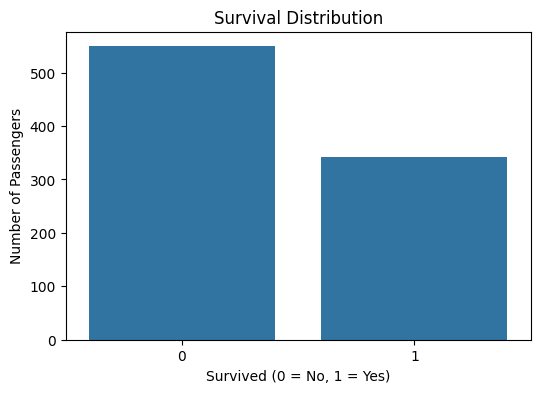

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [82]:
df.groupby("Sex")["Survived"].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [83]:
survival_by_gender = df.groupby("Sex")["Survived"].mean() * 100
survival_by_gender

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

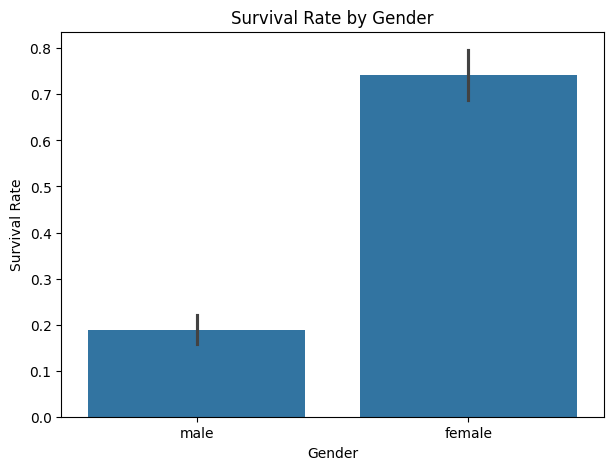

In [84]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Sex",
    y="Survived"
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

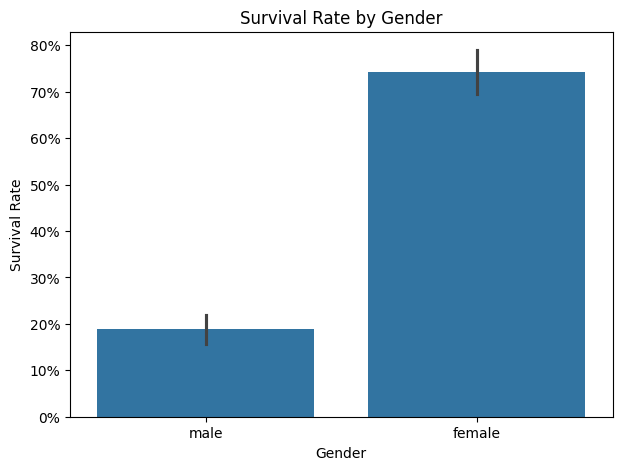

In [85]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Sex",
    y="Survived"
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.show()

In [86]:
survival_by_gender

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [88]:
# Does Passenger Class Affect Survival?
df.groupby("Pclass")["Survived"].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [91]:
"""
1 - First Class
2 - Second Class
3 - Third Class
"""

'\n1  First Class\n2  Second Class\n3  Third Class\n'

In [93]:
# Survival count 
df.groupby("Pclass")["Survived"].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [94]:
# Calculating Survival Rate
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
survival_by_class

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

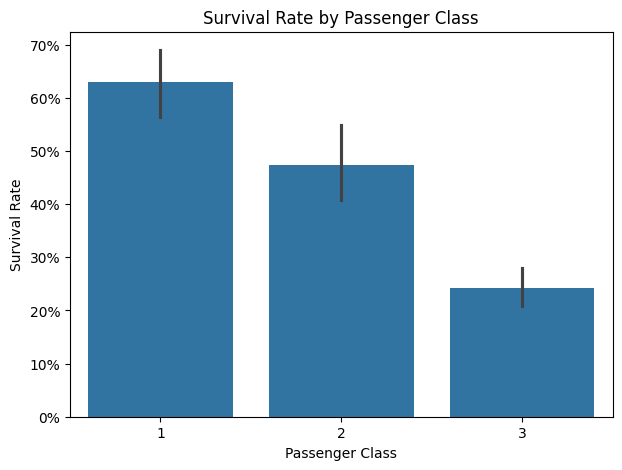

In [95]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.show()

In [96]:
# What was the age distribution of Titanic passengers?
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

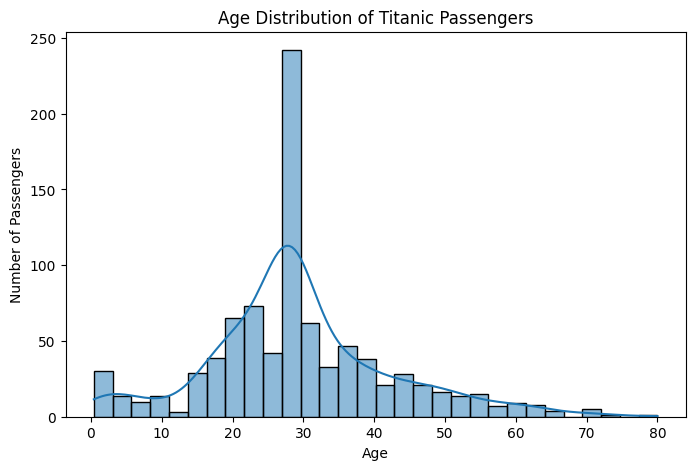

In [97]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [98]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

In [99]:
survival_by_age_group = df.groupby(
    "AgeGroup",
    observed=True
)["Survived"].mean() * 100

survival_by_age_group

AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

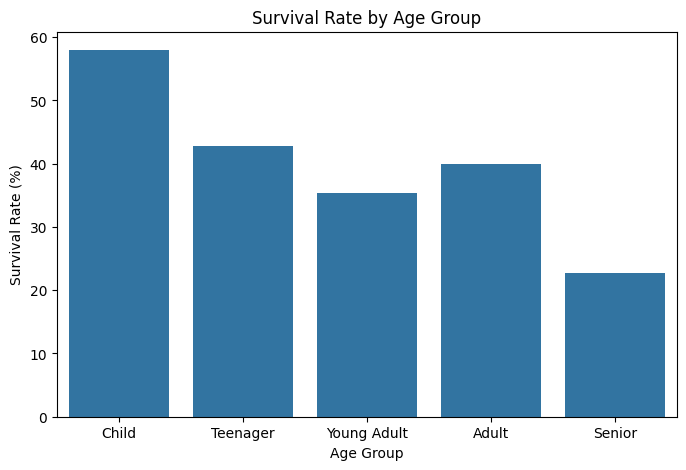

In [100]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=survival_by_age_group.index,
    y=survival_by_age_group.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

plt.show()

In [101]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [102]:
df.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

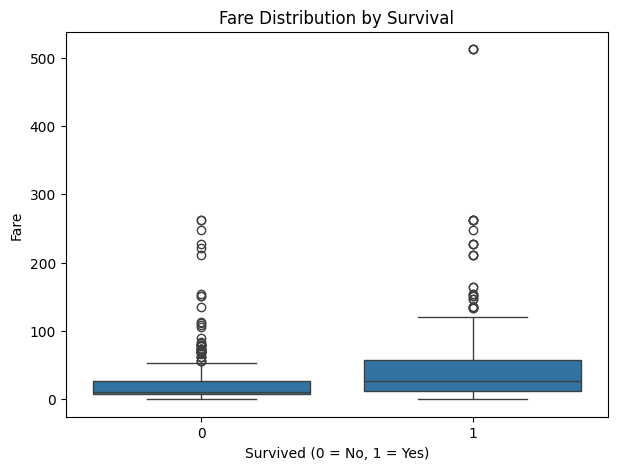

In [103]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

In [104]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [105]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [107]:
"""
Why + 1?
Because SibSp and Parch count the other family members, while the passenger themselves is also part of the family group.
"""

'\nWhy + 1?\nBecause SibSp and Parch count the other family members, while the passenger themselves is also part of the family group.\n'

In [106]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [108]:
survival_by_family = df.groupby("FamilySize")["Survived"].mean() * 100
survival_by_family

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

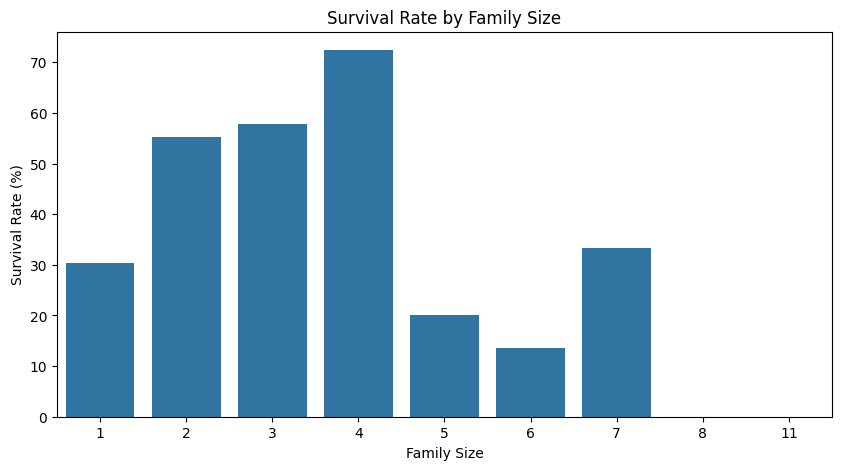

In [109]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=survival_by_family.index,
    y=survival_by_family.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

In [113]:
#Did survival rates differ depending on where passengers boarded the Titanic?

In [110]:
#Checking passenger counts by port
df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [111]:
survival_by_embarked = df.groupby("Embarked")["Survived"].mean() * 100
survival_by_embarked

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

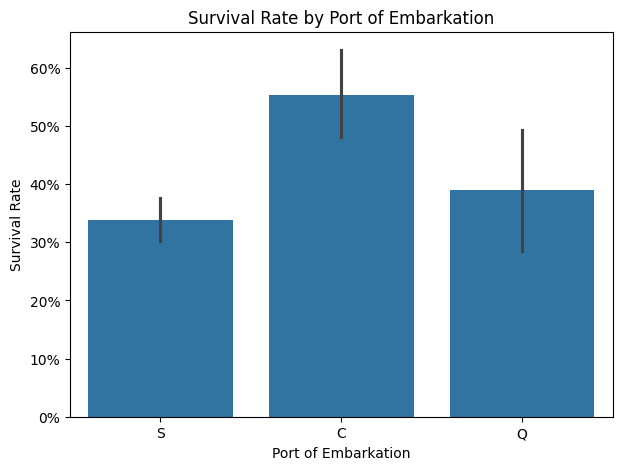

In [112]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Embarked",
    y="Survived"
)

plt.title("Survival Rate by Port of Embarkation")
plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.show()

In [114]:
#Gender + Passenger Class

In [116]:
#Calculate survival rate by gender and class
survival_gender_class = (
    df.groupby(["Pclass", "Sex"])["Survived"]
    .mean() * 100
)

survival_gender_class

Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64

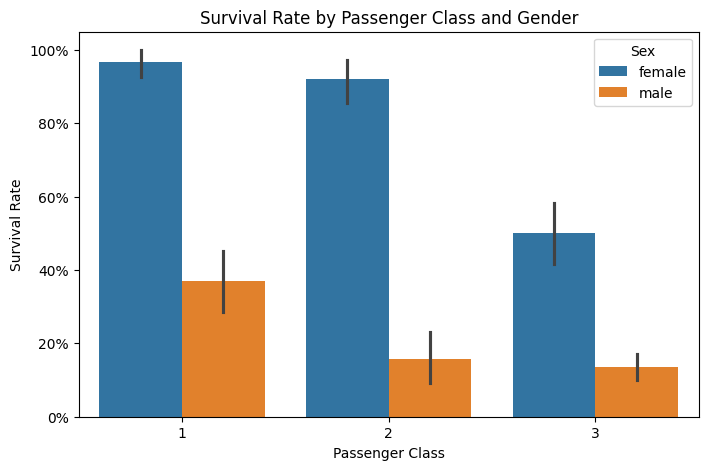

In [117]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.show()

In [118]:
#Correlation Analysis
numeric_cols = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]
correlation = df[numeric_cols].corr()
correlation

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


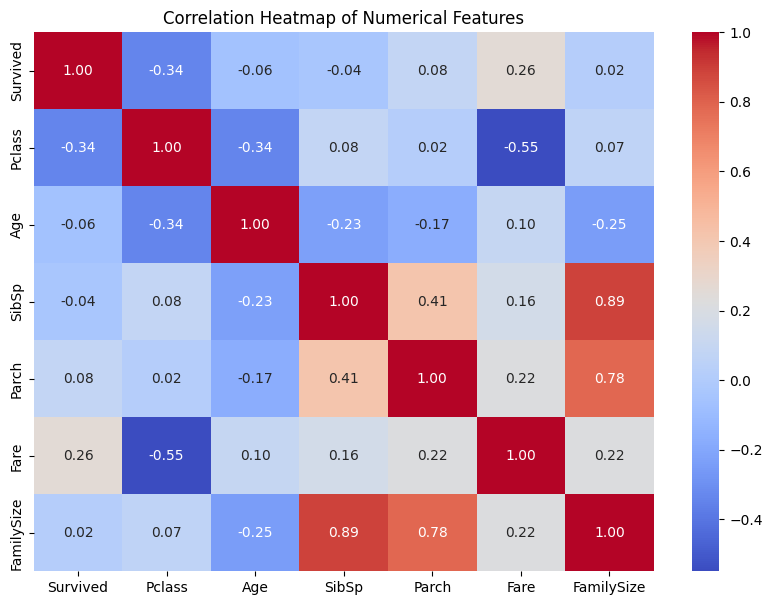

In [120]:

#Creating heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [121]:
"""
-1 → Strong negative relationship
 0 → No linear relationship
+1 → Strong positive relationship
"""

'\n-1 → Strong negative relationship\n 0 → No linear relationship\n+1 → Strong positive relationship\n'

In [122]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_Available,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,0.228956,1.904602
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,0.420397,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,0.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,11.000000


In [123]:
df.describe(include="object")

C:\Users\SRIDHAR\AppData\Local\Temp\ipykernel_8896\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Braund, Mr. Owen Harris",male,347082,S
freq,1,577,7,646


In [124]:
df.shape

(891, 14)

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    int64   
 3   Name             891 non-null    str     
 4   Sex              891 non-null    str     
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    str     
 9   Fare             891 non-null    float64 
 10  Embarked         891 non-null    str     
 11  Cabin_Available  891 non-null    int64   
 12  AgeGroup         891 non-null    category
 13  FamilySize       891 non-null    int64   
dtypes: category(1), float64(2), int64(7), str(4)
memory usage: 126.0 KB


In [127]:
## Key Findings
"""
1. Female passengers had a substantially higher survival rate than male passengers.

2. First-class passengers had the highest survival rate, while third-class passengers had the lowest.

3. Children showed the highest survival rate among the defined age groups, while seniors showed the lowest.

4. Passengers who survived had a higher average ticket fare than passengers who did not survive.

5. Small family groups generally showed higher survival rates than passengers traveling alone or in larger groups.

6. Passengers who embarked at Cherbourg had the highest observed survival rate among the three ports.

7. Gender and passenger class together showed a strong association with survival, with female passengers having higher survival rates across all passenger classes.

8. Correlation analysis showed a negative relationship between Pclass and survival and a positive relationship between Fare and survival.

"""

'\n1. Female passengers had a substantially higher survival rate than male passengers.\n\n2. First-class passengers had the highest survival rate, while third-class passengers had the lowest.\n\n3. Children showed the highest survival rate among the defined age groups, while seniors showed the lowest.\n\n4. Passengers who survived had a higher average ticket fare than passengers who did not survive.\n\n5. Small family groups generally showed higher survival rates than passengers traveling alone or in larger groups.\n\n6. Passengers who embarked at Cherbourg had the highest observed survival rate among the three ports.\n\n7. Gender and passenger class together showed a strong association with survival, with female passengers having higher survival rates across all passenger classes.\n\n8. Correlation analysis showed a negative relationship between Pclass and survival and a positive relationship between Fare and survival.\n\n'

In [ ]:
## Conclusion

"" The exploratory data analysis of the Titanic dataset revealed several important patterns related to passenger survival. 
Gender and passenger class showed strong associations with survival, with female and first-class passengers generally having higher survival rates. 
Age groups, ticket fare, family size, and embarkation port also showed differences in survival outcomes. 
Correlation analysis further indicated relationships between survival, passenger class, and fare. 
Overall, the analysis demonstrates how data cleaning, statistical summaries, and visualization can be used to identify meaningful patterns in a real-world dataset.
"""
    